# Pet Recommendation System

### Exploratory Data Analysis and Classification Model

This notebook builds a system that recommends the most suitable pet breed based on the adopting household's circumstances, including:

- Housing type and access to outdoor space
- Daily hours available for pet care
- Experience level, budget, and personal preferences (activity level, noise tolerance, etc.)

**Contents**

1. Import Libraries
2. Load Dataset
3. Initial Data Exploration
4. Data Quality Check
5. Exploratory Data Analysis
6. Breed Characteristics Overview
7. Reference Consistency Analysis
8. Key Findings
9. Modeling (next steps)

---

## 1. Import Libraries

The libraries needed across the project:

- `pandas` / `numpy` for data manipulation
- `matplotlib` / `seaborn` for visualization
- `scikit-learn` for building and evaluating the classification model (Random Forest)

In [1]:
# ==========================
# Import Libraries
# ==========================

# Data manipulation
import pandas as pd
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

Two files are loaded:

- `pet_recommendation_dataset.csv`: the main dataset, one row per pet and its household
- `breed_characteristics.csv`: reference characteristics for each breed

In [2]:
# ==========================
# Load Dataset
# ==========================
dataset = pd.read_csv("pet_recommendation_dataset.csv")
breed_info = pd.read_csv("breed_characteristics.csv")

## 3. Initial Data Exploration

A first look at the shape, structure, and data types before any analysis.

### First 5 rows

In [3]:
dataset.head()

,pet_id,birth_day,age,gender,country,registration_date,housing_type,outdoor_space,family_type,hours_available,...,activity_level,noise_tolerance,budget_level,maintenance_tolerance,size_preference,grooming_tolerance,energy_preference,affection_preference,animal_type,breed
0,PET_071788,2024-02-04,2,Female,United Arab Emirates,2024-03-27,house,balcony,couple,medium,...,medium,low,low,medium,small,low,medium,independent,bird,Button Quail
1,PET_067219,2016-09-07,10,Female,Saudi Arabia,2016-11-26,house,garden,couple,medium,...,medium,medium,medium,medium,small,low,low,balanced,bird,Pionus Parrot
2,PET_054067,2018-07-09,8,Female,United States,2019-01-20,apartment,none,couple,high,...,high,high,low,high,small,high,low,very_affectionate,bird,Cockatoo
3,PET_007169,2015-12-16,11,Male,United States,2016-04-24,house,garden,alone,high,...,high,medium,high,high,medium,high,medium,independent,dog,Poodle
4,PET_029619,2020-09-22,6,Male,Saudi Arabia,2021-05-09,apartment,garden,couple,low,...,low,high,medium,low,medium,low,medium,balanced,cat,British Shorthair


### Last 5 rows

In [4]:
dataset.tail()

,pet_id,birth_day,age,gender,country,registration_date,housing_type,outdoor_space,family_type,hours_available,...,activity_level,noise_tolerance,budget_level,maintenance_tolerance,size_preference,grooming_tolerance,energy_preference,affection_preference,animal_type,breed
119995,PET_110269,2022-05-25,4,Female,United States,2023-03-26,house,balcony,alone,medium,...,medium,medium,low,low,large,low,low,balanced,turtle,Russian Tortoise
119996,PET_119880,2019-07-29,7,Male,Australia,2019-09-24,apartment,large_yard,couple,low,...,low,low,low,low,small,low,low,independent,turtle,Mud Turtle
119997,PET_103695,2016-09-25,10,Female,United States,2017-06-25,house,none,family_with_children,medium,...,medium,low,low,low,large,low,medium,independent,hamster,Teddy Bear Hamster
119998,PET_000861,2023-07-07,3,Female,Germany,2024-05-29,house,balcony,family_with_children,medium,...,high,high,medium,high,small,medium,high,very_affectionate,dog,Labrador Retriever
119999,PET_015796,2016-08-09,10,Female,Saudi Arabia,2016-10-25,house,large_yard,family_with_children,medium,...,high,medium,medium,high,large,high,high,balanced,dog,Australian Shepherd


### Dataset dimensions

In [5]:
print(f"Rows    : {dataset.shape[0]}")
print(f"Columns : {dataset.shape[1]}")

Rows    : 120000
Columns : 23


### Column names

In [6]:
dataset.columns

Index(['pet_id', 'birth_day', 'age', 'gender', 'country', 'registration_date',
       'housing_type', 'outdoor_space', 'family_type', 'hours_available',
       'weekend_time', 'experience_level', 'training_ability',
       'activity_level', 'noise_tolerance', 'budget_level',
       'maintenance_tolerance', 'size_preference', 'grooming_tolerance',
       'energy_preference', 'affection_preference', 'animal_type', 'breed'],
      dtype='object')

### Data types per column

In [7]:
dataset.dtypes

pet_id                   object
birth_day                object
age                       int64
gender                   object
country                  object
registration_date        object
housing_type             object
outdoor_space            object
family_type              object
hours_available          object
weekend_time             object
experience_level         object
training_ability         object
activity_level           object
noise_tolerance          object
budget_level             object
maintenance_tolerance    object
size_preference          object
grooming_tolerance       object
energy_preference        object
affection_preference     object
animal_type              object
breed                    object
dtype: object

### Summary info

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   pet_id                 120000 non-null  object
 1   birth_day              120000 non-null  object
 2   age                    120000 non-null  int64 
 3   gender                 120000 non-null  object
 4   country                120000 non-null  object
 5   registration_date      120000 non-null  object
 6   housing_type           120000 non-null  object
 7   outdoor_space          120000 non-null  object
 8   family_type            120000 non-null  object
 9   hours_available        120000 non-null  object
 10  weekend_time           120000 non-null  object
 11  experience_level       120000 non-null  object
 12  training_ability       120000 non-null  object
 13  activity_level         120000 non-null  object
 14  noise_tolerance        120000 non-null  object
 15  

### Descriptive statistics (numeric columns)

In [9]:
dataset.describe()

,age
count,120000.000000
mean,7.009650
std,3.163836
min,2.000000
25%,4.000000
50%,7.000000
75%,10.000000
max,12.000000


## 4. Data Quality Check

Before analysis, it's worth confirming there are no missing values, no duplicate rows, and understanding how many unique values each categorical column holds.

### Missing values

Only columns that actually contain missing values are shown, so the result is easy to scan even on wide datasets.

In [10]:
missing = dataset.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

### Duplicate rows

In [11]:
duplicates = dataset.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


### Unique values per column

In [12]:
dataset.nunique()

pet_id                   120000
birth_day                  4018
age                          11
gender                        2
country                       8
registration_date          4331
housing_type                  3
outdoor_space                 4
family_type                   3
hours_available               3
weekend_time                  3
experience_level              3
training_ability              3
activity_level                3
noise_tolerance               3
budget_level                  3
maintenance_tolerance         3
size_preference               3
grooming_tolerance            3
energy_preference             3
affection_preference          3
animal_type                   7
breed                       100
dtype: int64

## 5. Exploratory Data Analysis

This section looks at the distribution of key variables and the relationships between categorical columns, to understand patterns before modeling.

### 5.1 Animal type distribution

In [13]:
dataset['animal_type'].value_counts()

animal_type
bird       24000
dog        24000
cat        24000
hamster    12000
turtle     12000
rabbit     12000
fish       12000
Name: count, dtype: int64

Relative share of each animal type, as a percentage:

In [14]:
dataset['animal_type'].value_counts(normalize=True) * 100

animal_type
bird       20.0
dog        20.0
cat        20.0
hamster    10.0
turtle     10.0
rabbit     10.0
fish       10.0
Name: proportion, dtype: float64

Count of pets by animal type:

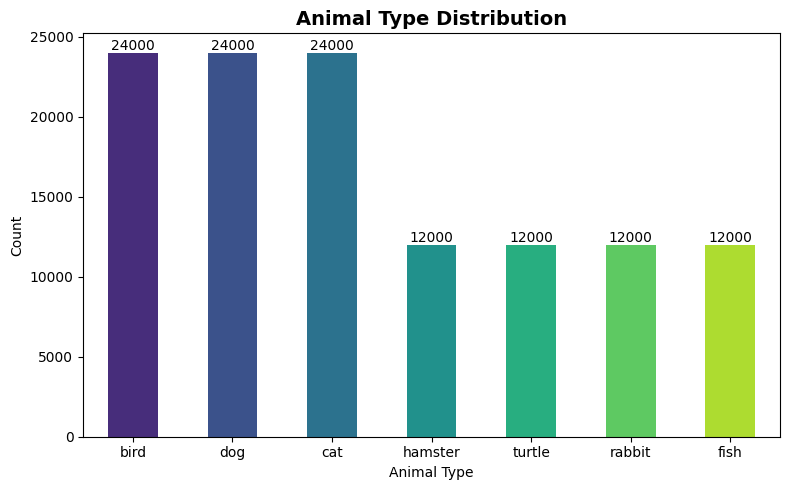

In [15]:
plt.figure(figsize=(8, 5))

ax = dataset['animal_type'].value_counts().plot(
    kind='bar', color=sns.color_palette('viridis', dataset['animal_type'].nunique())
)

plt.title("Animal Type Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

The same distribution as a pie chart, to make the relative proportions easier to read at a glance:

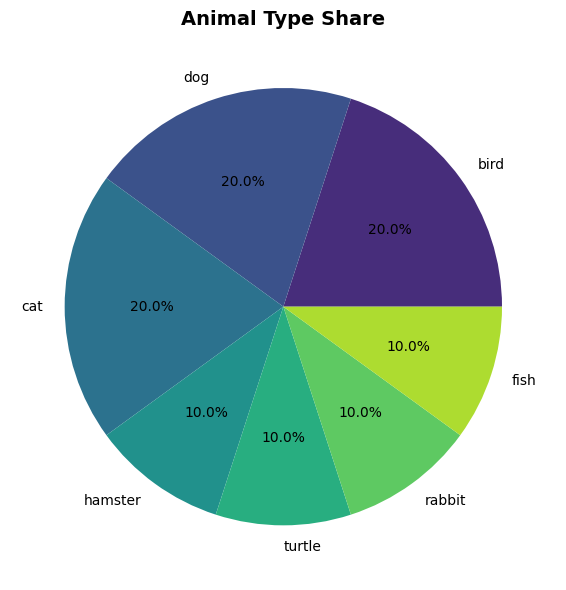

In [16]:
plt.figure(figsize=(6, 6))

dataset['animal_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', dataset['animal_type'].nunique()),
    ylabel=''
)

plt.title("Animal Type Share", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Breed distribution

In [17]:
breed_counts = dataset['breed'].value_counts()
breed_counts.head()

breed
Button Quail         1200
Pionus Parrot        1200
Cockatoo             1200
Poodle               1200
British Shorthair    1200
Name: count, dtype: int64

Summary statistics on how often each breed appears:

In [18]:
breed_counts.describe()

count     100.0
mean     1200.0
std         0.0
min      1200.0
25%      1200.0
50%      1200.0
75%      1200.0
max      1200.0
Name: count, dtype: float64

### 5.3 Housing type distribution

In [19]:
dataset['housing_type'].value_counts()

housing_type
house        55815
apartment    51674
farm         12511
Name: count, dtype: int64

Count of pets by housing type:

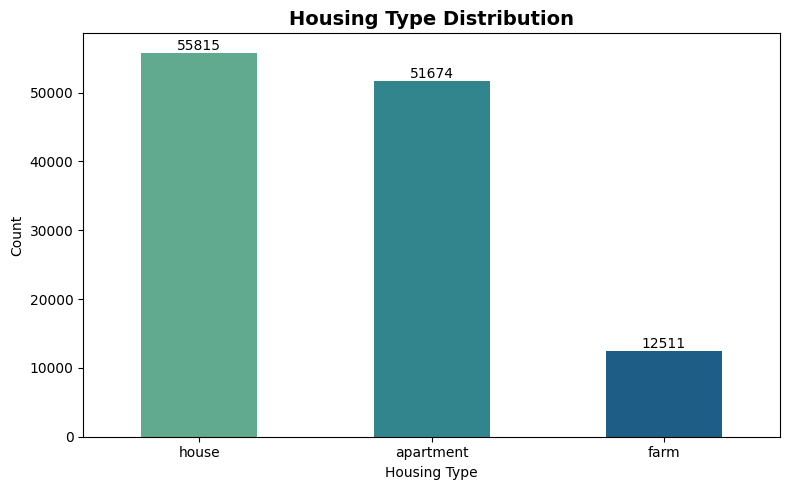

In [20]:
plt.figure(figsize=(8, 5))

ax = dataset['housing_type'].value_counts().plot(
    kind='bar', color=sns.color_palette('crest', dataset['housing_type'].nunique())
)

plt.title("Housing Type Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Housing Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 5.4 Family type

In [21]:
dataset['family_type'].value_counts()

family_type
family_with_children    59902
couple                  36194
alone                   23904
Name: count, dtype: int64

### 5.5 Experience level

In [22]:
dataset['experience_level'].value_counts()

experience_level
beginner        56555
intermediate    35250
expert          28195
Name: count, dtype: int64

### 5.6 Activity level

In [23]:
dataset['activity_level'].value_counts()

activity_level
high      43158
medium    41441
low       35401
Name: count, dtype: int64

### 5.7 Budget level

In [24]:
dataset['budget_level'].value_counts()

budget_level
medium    48408
low       39598
high      31994
Name: count, dtype: int64

### 5.8 Cross-tabulation analysis

`pd.crosstab` is used to study the relationship between two categorical variables, which helps understand how household circumstances relate to the recommended breed.

**Animal type vs. housing type**

In [25]:
pd.crosstab(dataset['animal_type'],
            dataset['housing_type'])

housing_type,apartment,farm,house
animal_type,,,
bird,9660,2382,11958
cat,13318,1247,9435
dog,7883,4612,11505
fish,6028,588,5384
hamster,6025,544,5431
rabbit,4784,1181,6035
turtle,3976,1957,6067


**Breed vs. experience level**

In [26]:
pd.crosstab(dataset['breed'],
            dataset['experience_level'])

experience_level,beginner,expert,intermediate
breed,,,
Abyssinian,109,102,989
African Grey Parrot,113,975,112
Albino Syrian Hamster,1007,80,113
Amazon Parrot,120,954,126
American Shorthair,984,107,109
...,...,...,...
Turkish Angora,103,125,972
Winter White Dwarf Hamster,995,94,111
Yorkshire Terrier,1011,90,99


**Breed vs. budget level**

In [27]:
pd.crosstab(dataset['breed'],
            dataset['budget_level'])

budget_level,high,low,medium
breed,,,
Abyssinian,108,98,994
African Grey Parrot,984,104,112
Albino Syrian Hamster,111,979,110
Amazon Parrot,992,103,105
American Shorthair,112,990,98
...,...,...,...
Turkish Angora,105,110,985
Winter White Dwarf Hamster,121,958,121
Yorkshire Terrier,97,97,1006


## 6. Breed Characteristics Overview

The main dataset only describes what each household is looking for. The `breed_info` file loaded earlier holds the actual reference characteristics of the 100 breeds used to generate those recommendations, and it hasn't been explored yet.

### First 5 rows

In [28]:
breed_info.head()

,breed,animal_type,size,energy,grooming,trainability,noise,maintenance,budget,experience,affection,kid_friendly
0,Labrador Retriever,dog,large,high,medium,high,medium,medium,medium,beginner,very_affectionate,high
1,German Shepherd,dog,large,high,medium,high,medium,high,high,expert,balanced,medium
2,Golden Retriever,dog,large,high,high,high,medium,medium,medium,beginner,very_affectionate,high
3,French Bulldog,dog,small,low,low,medium,low,medium,high,beginner,very_affectionate,high
4,Beagle,dog,medium,high,low,medium,high,medium,medium,intermediate,very_affectionate,high


### Summary info

In [29]:
breed_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   breed         100 non-null    object
 1   animal_type   100 non-null    object
 2   size          100 non-null    object
 3   energy        100 non-null    object
 4   grooming      100 non-null    object
 5   trainability  100 non-null    object
 6   noise         100 non-null    object
 7   maintenance   100 non-null    object
 8   budget        100 non-null    object
 9   experience    100 non-null    object
 10  affection     100 non-null    object
 11  kid_friendly  100 non-null    object
dtypes: object(12)
memory usage: 9.5+ KB


### Descriptive statistics (all columns)

In [30]:
breed_info.describe(include='all')

,breed,animal_type,size,energy,grooming,trainability,noise,maintenance,budget,experience,affection,kid_friendly
count,100,100,100,100,100,100,100,100,100,100,100,100
unique,100,7,3,3,3,3,3,3,3,3,3,3
top,Labrador Retriever,dog,small,high,low,low,low,medium,medium,beginner,very_affectionate,high
freq,1,20,47,37,68,38,60,42,43,52,38,64


This dataset contains the reference characteristics of all 100 breeds used in the recommendation system.

## 7. Reference Consistency Analysis

The main dataset contains the *preferences* each household expressed (`energy_preference`, `experience_level`, `budget_level`, `noise_tolerance`), while `breed_info` contains the *actual* characteristics of the breed that was recommended to them (`energy`, `experience`, `budget`, `noise`).

Merging the two and comparing preference against actual characteristic checks whether the recommendations in the dataset are consistent rather than random.

**Note:** the column names below (`energy`, `experience`, `budget`, `noise`) are assumed based on `breed_info`'s expected structure. If `breed_info.columns` shows different names, adjust the merge/crosstab calls accordingly.

### Merge the two datasets on breed and animal type

In [31]:
merged = dataset.merge(
    breed_info,
    on=['breed', 'animal_type'],
    how='left'
)

merged.shape

(120000, 33)

### Energy preference vs. breed energy

In [32]:
pd.crosstab(
    merged['energy_preference'],
    merged['energy']
)

energy,high,low,medium
energy_preference,,,
high,36531,3044,3660
low,3938,27585,3761
medium,3931,2971,34579


### Experience level vs. breed experience requirement

In [33]:
pd.crosstab(
    merged['experience_level'],
    merged['experience']
)

experience,beginner,expert,intermediate
experience_level,,,
beginner,51260,2185,3110
expert,5553,19631,3011
intermediate,5587,2184,27479


### Budget level vs. breed budget requirement

In [34]:
pd.crosstab(
    merged['budget_level'],
    merged['budget']
)

budget,high,low,medium
budget_level,,,
high,23718,3619,4657
low,2551,32458,4589
medium,2531,3523,42354


### Noise tolerance vs. breed noise level

In [35]:
pd.crosstab(
    merged['noise_tolerance'],
    merged['noise']
)

noise,high,low,medium
noise_tolerance,,,
high,14927,10590,7268
low,731,32376,4337
medium,3542,29034,17195


### Visualizing consistency with heatmaps

Heatmaps make it easier to spot whether values cluster along the diagonal (i.e. preference matches the breed's actual characteristic), which is what would be expected from a well-generated dataset.

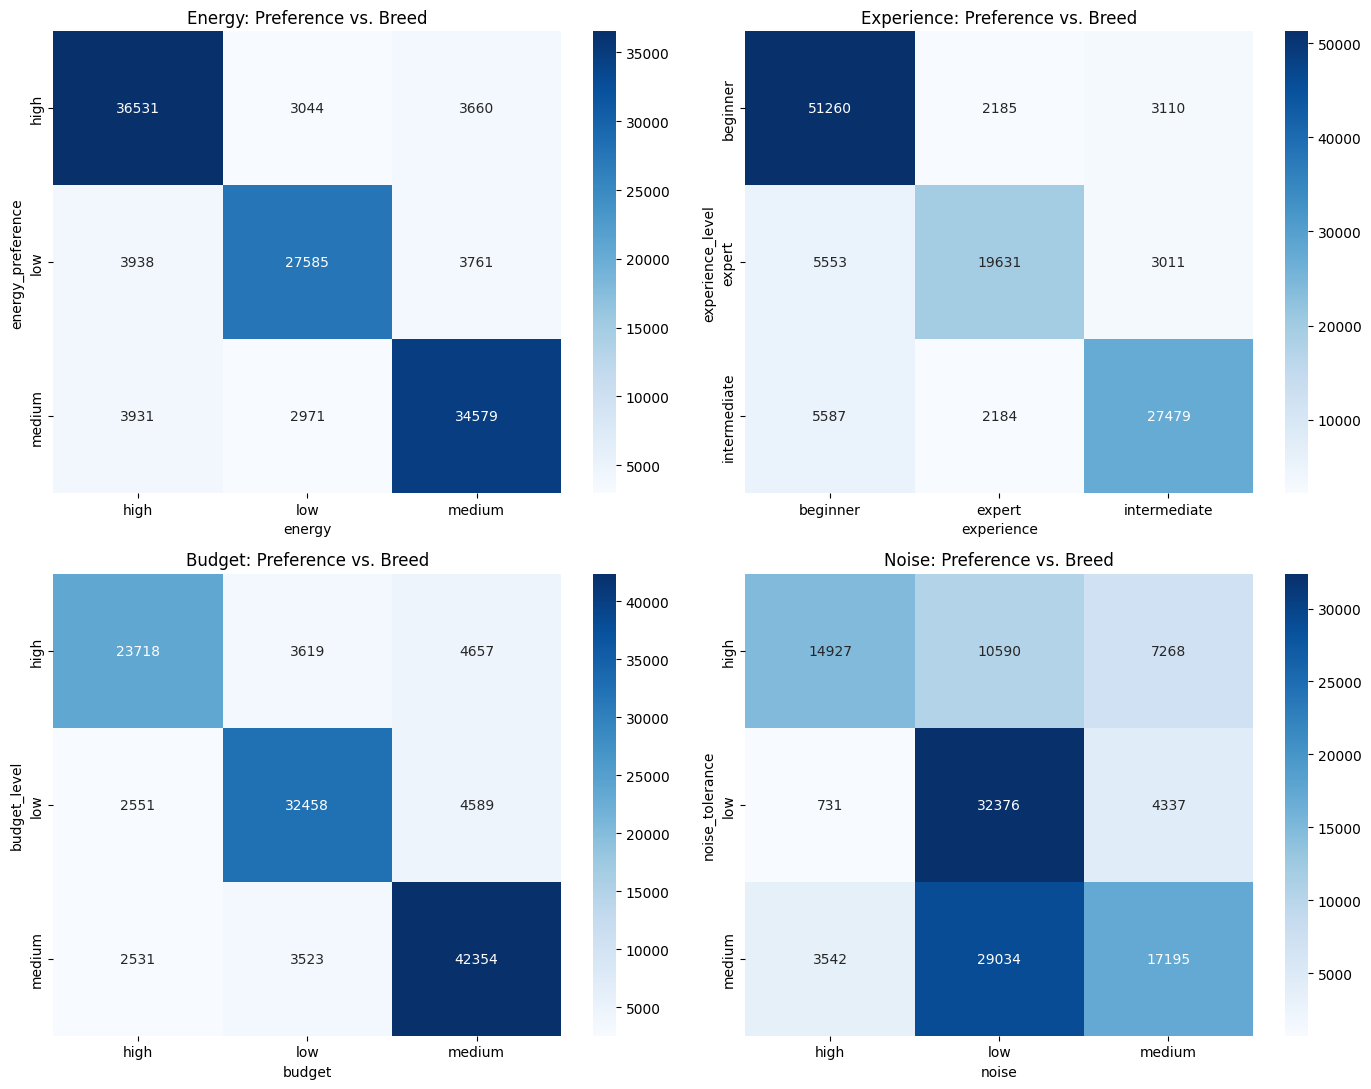

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

pairs = [
    ('energy_preference', 'energy', 'Energy: Preference vs. Breed'),
    ('experience_level', 'experience', 'Experience: Preference vs. Breed'),
    ('budget_level', 'budget', 'Budget: Preference vs. Breed'),
    ('noise_tolerance', 'noise', 'Noise: Preference vs. Breed'),
]

for ax, (pref_col, ref_col, title) in zip(axes.flat, pairs):
    sns.heatmap(
        pd.crosstab(merged[pref_col], merged[ref_col]),
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 8. Key Findings

- The dataset contains 120,000 records split across 100 breeds, roughly 1,200 records per breed.
- No missing values or duplicate rows were detected.
- Animal types, housing types, and family types are all realistically distributed rather than uniform or skewed to a single category.
- Cross-tabulating breed against experience level and budget level shows a clear majority class per breed, consistent with breed-specific recommendation logic rather than random assignment.
- Merging with `breed_info` and comparing stated preferences against actual breed characteristics (energy, experience, budget, noise) shows the same pattern: values concentrate around matching categories, suggesting the recommendations in the dataset are internally consistent.

With data quality confirmed and the reference file validated against the main dataset, the notebook is ready to move on to **Data Preprocessing** and model training.

---
## Next Steps

1. Encode categorical columns using `OneHotEncoder` / `OrdinalEncoder`.
2. Split the data into train and test sets with `train_test_split`.
3. Train a `RandomForestClassifier` to predict the most suitable breed or animal type.
4. Evaluate the model with `accuracy_score`, `classification_report`, and `confusion_matrix`.

All the tools needed for these steps were already imported in the first cell above.